### Library

In [1]:
%matplotlib inline
import os, json, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
import torch.nn.functional as F
import torch.optim as optim
import torch.amp as amp
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


### TCN Model

In [2]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class OptBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k_size, stride, dil, pad, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            weight_norm(nn.Conv1d(in_ch, out_ch, k_size, stride=stride, padding=pad, dilation=dil)),
            Chomp1d(pad), nn.SiLU(), nn.Dropout(drop),
            weight_norm(nn.Conv1d(out_ch, out_ch, k_size, stride=stride, padding=pad, dilation=dil)),
            Chomp1d(pad), nn.SiLU(), nn.Dropout(drop)
        )
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.res = nn.SiLU()
    def forward(self, x):
        return self.res(self.net(x) + (x if self.down is None else self.down(x)))

class QVAttn(nn.Module):
    def __init__(self, ch, drop=0.2):
        super().__init__()
        self.W_q = nn.Linear(ch, ch)
        self.W_v = nn.Linear(ch, ch)
        self.mlp = nn.Sequential(nn.Linear(ch, ch*2), nn.GELU(), nn.Linear(ch*2, ch), nn.Dropout(drop))
        self.ln = nn.LayerNorm(ch)
    def forward(self, x):
        z = x.permute(0, 2, 1)
        return self.ln(z + self.mlp(self.W_q(z) * self.W_v(z))).permute(0, 2, 1)

class WLASL_TCN(nn.Module):
    def __init__(self, in_dim, out_dim=400):
        super().__init__()
        self.bn = nn.BatchNorm1d(in_dim)
        chs = [128]*5
        self.adapt = nn.Conv1d(in_dim, chs[0], 1)
        layers = [OptBlock(chs[0] if i==0 else chs[i-1], chs[i], 3, 1, 2**i, 2*(2**i), 0.3) for i in range(5)]
        self.tcn = nn.Sequential(*layers)
        self.attn = QVAttn(chs[-1], 0.3)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.clf = nn.Linear(chs[-1], out_dim)
    def forward(self, x):
        return self.clf(self.pool(self.attn(self.tcn(self.adapt(self.bn(x))))).squeeze(-1))

class AUTSL_TCN(nn.Module):
    def __init__(self, in_dim, out_dim=400):
        super().__init__()
        self.bn = nn.BatchNorm1d(in_dim)
        chs = [64]*3
        self.adapt = nn.Conv1d(in_dim, chs[0], 1)
        layers = [OptBlock(chs[0] if i==0 else chs[i-1], chs[i], 3, 1, 2**i, 2*(2**i), 0.5) for i in range(3)]
        self.tcn = nn.Sequential(*layers)
        self.attn = QVAttn(chs[-1], 0.5)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.clf = nn.Linear(chs[-1], out_dim)
    def forward(self, x):
        return self.clf(self.pool(self.attn(self.tcn(self.adapt(self.bn(x))))).squeeze(-1))


### Cấu trúc nạp dữ liệu (DataLoader) và các hàm tiện ích


In [3]:
OUTPUT_DIR = '/kaggle/working/benchmark_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

class SignDataset(Dataset):
    def __init__(self, x, y, max_f=100):
        self.x, self.y, self.max_f = x, y, max_f
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        v = self.x[i]
        return self.x[i].float().transpose(0, 1), torch.tensor(self.y[i], dtype=torch.long)

def load_wlasl(split='train'):
    cache_path = os.path.join(OUTPUT_DIR, f'wlasl_{split}.pt')
    if os.path.exists(cache_path):
        print(f"Loaded WLASL {split} from cache!")
        return torch.load(cache_path, weights_only=False)
        
    p1 = '/kaggle/input/datasets/abd0kamel/mutemotion-output/WLASL_parsed_data.json'
    p2 = '/kaggle/input/datasets/abd0kamel/mutemotion-output/landmarks_V3.npz'
    if not (os.path.exists(p1) and os.path.exists(p2)): return [], []
    with open(p1, 'r') as f: meta = json.load(f)
    data = np.load(p2)
    gm = {g: i for i, g in enumerate(sorted(list(set([i['gloss'] for i in meta]))))}
    ids = train_test_split(sorted(list(data.files)), test_size=0.2, random_state=42)[0 if split=='train' else 1]
    x, y = [], []
    for vid in ids:
        item = next((i for i in meta if os.path.basename(i['video_path']).startswith(vid)), None)
        if item:
            f = data[vid].reshape(data[vid].shape[0], -1)
            f_norm = ((f - np.mean(f)) / (np.std(f) + 1e-6)).astype(np.float32)
            f_norm = np.nan_to_num(f_norm, nan=0.0)
            if f_norm.shape[0] < 100:
                f_norm = np.concatenate([f_norm, np.zeros((100 - f_norm.shape[0], f_norm.shape[1]), dtype=np.float32)])
            x.append(torch.from_numpy(f_norm[:100]))
            y.append(gm[item['gloss']])
    print(f'WLASL {split}: {len(x)} samples')
    x = torch.stack(x)
    torch.save((x, y), cache_path)
    return x, y

def load_autsl(split='train'):
    cache_path = os.path.join(OUTPUT_DIR, f'autsl_{split}.pt')
    if os.path.exists(cache_path):
        print(f"Loaded AUTSL {split} from cache!")
        return torch.load(cache_path, weights_only=False)
        
    p = f'/kaggle/input/datasets/trnvngquct/austl-processed-dataset-mediapipe-landmarks/AUSTL_processed_landmark/{split}.csv'
    d = '/kaggle/input/datasets/trnvngquct/austl-processed-dataset-mediapipe-landmarks/AUSTL_processed_landmark'
    if not os.path.exists(p): return [], []
    df = pd.read_csv(p)
    am = {i: i for i in range(226)}
    x, y = [], []
    for _, r in df.sample(n=1500, random_state=42).iterrows():
        fp = os.path.join(d, r["path"])
        if not os.path.exists(fp): continue
        dp = pd.read_parquet(fp).sort_values(["frame", "type", "landmark_index"])
        frames = [f[["x", "y", "z"]].to_numpy(dtype=np.float32).flatten() for _, f in dp.groupby("frame")]
        f = np.stack(frames, axis=0)
        f_norm = ((f - 0.5) / 0.5).astype(np.float32)
        f_norm = np.nan_to_num(f_norm, nan=0.0)
        if f_norm.shape[0] < 100:
            f_norm = np.concatenate([f_norm, np.zeros((100 - f_norm.shape[0], f_norm.shape[1]), dtype=np.float32)])
        x.append(torch.from_numpy(f_norm[:100]))
        y.append(am[int(r["sign"])])
    print(f'AUTSL {split}: {len(x)} samples')
    x = torch.stack(x)
    torch.save((x, y), cache_path)
    return x, y

def plot_loss(loss, title):
    plt.figure(figsize=(6, 3))
    plt.plot(loss, lw=2)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

def train(name, x, y, epochs=300):
    if not y: return None, []
    dim = x[0].shape[1]
    cls = 2000 if name == 'WLASL' else 226
    
    model = WLASL_TCN(dim, cls) if name=='WLASL' else AUTSL_TCN(dim, cls)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model = model.to(device)
    
    opt = optim.Adam(model.parameters(), lr=0.0001)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    loader = DataLoader(SignDataset(x, y), batch_size=64, shuffle=True, num_workers=1, pin_memory=False)
    
    scaler = amp.GradScaler('cuda')
    losses = []
    
    best_loss = float('inf')
    patience_counter = 0
    patience_limit = 100
    
    model.train()
    for ep in range(epochs):
        tot = 0
        for ins, tgts in loader:
            opt.zero_grad()
            ins, tgts = ins.to(device), tgts.to(device)
            
            with amp.autocast('cuda'):
                out = model(ins)
                loss = crit(out, tgts)
                
            if torch.isnan(loss): continue
            
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(opt)
            scaler.update()
            
            tot += loss.item()
            
        avg_loss = tot/len(loader)
        losses.append(avg_loss)
        if (ep+1) % 50 == 0: print(f'Epoch {ep+1}/{epochs} - Loss: {avg_loss:.4f}')
        
        if avg_loss < best_loss - 1e-4:
            best_loss = avg_loss
            patience_counter = 0
            state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(state_dict, os.path.join(OUTPUT_DIR, f'{name}_best.pth'))
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print(f"Early stopping at epoch {ep+1}")
                break
                
    return model, losses

def run_bm(name, x, y):
    if not y: return
    dim = x[0].shape[1]
    expected_cls = 2000 if name == 'WLASL' else 226
    cls = max(int(np.max(y)) + 1, expected_cls)
    
    model = WLASL_TCN(dim, cls) if name=='WLASL' else AUTSL_TCN(dim, cls)
    cp = os.path.join(OUTPUT_DIR, f'{name}_best.pth')
    
    if os.path.exists(cp):
        print(f"[Info] Đang load weights từ {cp}")
        try:
            model.load_state_dict(torch.load(cp, map_location=device))
        except Exception as e:
            print(f"[Lỗi nghiêm trọng] Không thể load weights: {e}")
            return
    else:
        print(f"[Cảnh báo] Không tìm thấy file {cp}! Model sẽ predict bằng random weights.")
        
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    model = model.to(device)
    model.eval()
    
    loader = DataLoader(SignDataset(x, y), batch_size=64, num_workers=0, pin_memory=False)
    cor, tot = 0, 0
    with torch.no_grad():
        for ins, tgts in loader:
            with amp.autocast('cuda'):
                preds = model(ins.to(device)).argmax(1)
            cor += (preds == tgts.to(device)).sum().item()
            tot += tgts.size(0)
    print(f'[{name} Benchmark] Độ chính xác (Accuracy): {100*cor/tot:.2f}%\n')


### Train model trên tập WLASL & Trực quan hóa Loss

WLASL train: 6030 samples
Epoch 50/400 - Loss: 6.0417
Epoch 100/400 - Loss: 4.7236
Epoch 150/400 - Loss: 3.4603
Epoch 200/400 - Loss: 2.4801
Epoch 250/400 - Loss: 1.8490
Epoch 300/400 - Loss: 1.5905
Epoch 350/400 - Loss: 1.4578
Epoch 400/400 - Loss: 1.4086


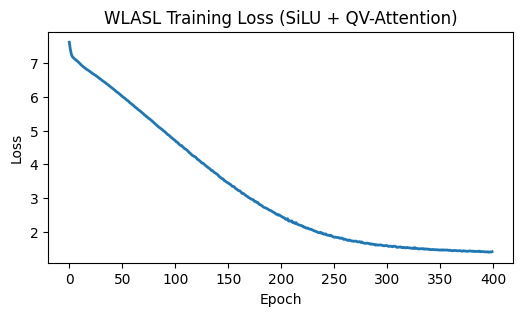

3334

In [4]:
x, y = load_wlasl('train')
m_w, l_w = train('WLASL', x, y, 400)
if l_w: plot_loss(l_w, 'WLASL Training Loss (SiLU + QV-Attention)')
del x, y
gc.collect()

### Train model trên tập AUTSL & Trực quan hóa Loss


AUTSL train: 1499 samples
Epoch 50/400 - Loss: 4.8413
Epoch 100/400 - Loss: 4.3256
Epoch 150/400 - Loss: 3.9438
Epoch 200/400 - Loss: 3.5744
Epoch 250/400 - Loss: 3.2514
Epoch 300/400 - Loss: 2.9500
Epoch 350/400 - Loss: 2.6666
Epoch 400/400 - Loss: 2.4167


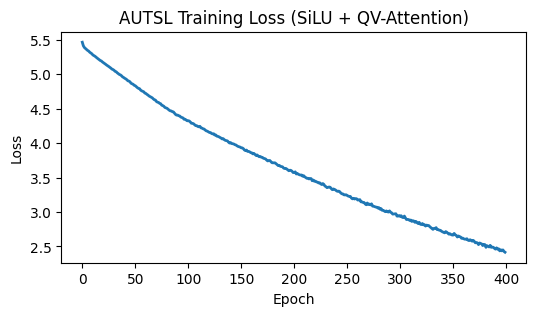

3495

In [5]:
x, y = load_autsl('train')
m_a, l_a = train('AUTSL', x, y, 400)
if l_a: plot_loss(l_a, 'AUTSL Training Loss (SiLU + QV-Attention)')
del x, y
gc.collect()

### Benchmark trên tập Test (WLASL)

In [6]:
x, y = load_wlasl('test')
run_bm('WLASL', x, y)
del x, y
gc.collect()

WLASL test: 1534 samples
[Info] Đang load weights từ /kaggle/working/benchmark_results/WLASL_best.pth
[WLASL Benchmark] Độ chính xác (Accuracy): 1.96%



913

### Benchmark trên tập Test (AUTSL)

In [7]:
x, y = load_autsl('test')
run_bm('AUTSL', x, y)
del x, y
gc.collect()

AUTSL test: 1499 samples
[Info] Đang load weights từ /kaggle/working/benchmark_results/AUTSL_best.pth
[AUTSL Benchmark] Độ chính xác (Accuracy): 16.14%



528

### Thông số máy chủ triển khai (Server Specs)
- **Môi trường:** Kaggle (Draft Session)
- **GPU:** 2x NVIDIA T4 (15GiB VRAM / card)
- **CPU:** 4 vCPUs
- **RAM:** 30GiB
- **Ổ cứng (Disk):** 57.6GiB Max